# 🐧 Linux Manuals Dataset — Full EDA
**Dataset:** [Masrkai/LinuxManuals](https://huggingface.co/datasets/Masrkai/LinuxManuals)  
**Size:** ~97,620 rows | 2 columns (`id`, `text`)  
**Tools:** Polars · Matplotlib · Seaborn · WordCloud

## 1. Install & Import

In [1]:
!pip install -q polars datasets matplotlib seaborn wordcloud

In [5]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'monospace'

print(f'Polars version: {pl.__version__}')

Polars version: 1.35.2


## 2. Load the Dataset

In [9]:
import dask.dataframe as dd

df = pl.read_ndjson("https://huggingface.co/datasets/Masrkai/LinuxManuals/resolve/main/manuals.json")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns}")
df.head(5)

Shape: (97620, 2)
Columns: ['id', 'text']


id,text
str,str
"""30-systemd-environment-d-gener…","""NAME systemd-environment-d-gen…"
"""7z(1)""","""NAME 7z - A file archiver with…"
"""7za(1)""","""NAME 7za - A file archiver wit…"
"""7zr(1)""","""NAME 7zr - A file archiver wit…"
"""ABORT(7)""","""NAME ABORT - abort the current…"


## 3. Schema & Basic Info

In [10]:
print("=== Schema ===")
print(df.schema)
print("\n=== Null Counts ===")
print(df.null_count())
print("\n=== Duplicates ===")
print(f"Duplicate rows: {df.is_duplicated().sum()}")
print(f"Unique IDs:     {df['id'].n_unique()}")

=== Schema ===
Schema({'id': String, 'text': String})

=== Null Counts ===
shape: (1, 2)
┌─────┬──────┐
│ id  ┆ text │
│ --- ┆ ---  │
│ u32 ┆ u32  │
╞═════╪══════╡
│ 0   ┆ 0    │
└─────┴──────┘

=== Duplicates ===
Duplicate rows: 0
Unique IDs:     97620


## 4. Feature Engineering

In [25]:
df = df.with_columns([

    # ---------------------------------------------------
    # BASIC TEXT STATISTICS
    # ---------------------------------------------------

    pl.col("text").str.len_chars().alias("char_count"),

    pl.col("text")
        .str.split(by=" ")
        .list.len()
        .alias("word_count"),

    pl.col("text")
        .str.split(by="\n")
        .list.len()
        .alias("line_count"),

    pl.col("text")
        .str.count_matches(r"[.!?]")
        .alias("sentence_count"),

    # Average word length
    (
        pl.col("text").str.len_chars() /
        pl.col("text").str.split(by=" ").list.len()
    ).alias("avg_word_length"),

    # Average words per sentence
    (
        pl.col("text").str.split(by=" ").list.len() /
        (
            pl.col("text").str.count_matches(r"[.!?]") + 1
        )
    ).alias("avg_sentence_length"),

    # ---------------------------------------------------
    # COMMAND EXTRACTION
    # ---------------------------------------------------

    pl.col("id")
        .str.extract(r"\((\d+[a-z]?)\)", 1)
        .alias("man_section"),

    pl.col("id")
        .str.extract(r"^([^(]+)", 1)
        .alias("command_name"),

    # ---------------------------------------------------
    # DOCUMENT STRUCTURE FEATURES
    # ---------------------------------------------------

    pl.col("text").str.contains(r"SYNOPSIS").alias("has_synopsis"),
    pl.col("text").str.contains(r"EXAMPLES?").alias("has_examples"),
    pl.col("text").str.contains(r"OPTIONS?|FLAGS?")
        .alias("has_options"),
    pl.col("text").str.contains(r"SEE ALSO")
        .alias("has_see_also"),
    pl.col("text").str.contains(r"BUGS?")
        .alias("has_bugs"),
    pl.col("text").str.contains(r"DESCRIPTION")
        .alias("has_description"),
    pl.col("text").str.contains(r"AUTHOR")
        .alias("has_author"),
    pl.col("text").str.contains(r"ENVIRONMENT")
        .alias("has_environment"),

    # Count ALL-CAPS section headers
    pl.col("text")
        .str.count_matches(r"\n[A-Z][A-Z ]+\n")
        .alias("section_header_count"),

    # ---------------------------------------------------
    # OPTION / FLAG ANALYSIS
    # ---------------------------------------------------

    # Count short flags like -a
    pl.col("text")
        .str.count_matches(r"\s-[a-zA-Z]\b")
        .alias("short_option_count"),

    # Count long flags like --help
    pl.col("text")
        .str.count_matches(r"--[a-zA-Z0-9_-]+")
        .alias("long_option_count"),

    # Total CLI options
    (
        pl.col("text").str.count_matches(r"\s-[a-zA-Z]\b") +
        pl.col("text").str.count_matches(r"--[a-zA-Z0-9_-]+")
    ).alias("total_option_count"),

    # ---------------------------------------------------
    # EXAMPLE / CODE DENSITY
    # ---------------------------------------------------

    # Shell prompt examples
    pl.col("text")
        .str.count_matches(r"(?m)^\$ ")
        .alias("shell_example_count"),

    # Paths
    pl.col("text")
        .str.count_matches(r"/[a-zA-Z0-9_/\.-]+")
        .alias("path_count"),

    # Commands in backticks
    pl.col("text")
        .str.count_matches(r"`[^`]+`")
        .alias("inline_code_count"),

    # ---------------------------------------------------
    # SECURITY / SYSTEM LEVEL FEATURES
    # ---------------------------------------------------

    pl.col("text")
        .str.contains(
            r"sudo|root|permission|privilege|authentication",
            literal=False
        )
        .alias("mentions_privileges"),

    pl.col("text")
        .str.contains(
            r"network|socket|tcp|udp|ssh|http|dns",
            literal=False
        )
        .alias("network_related"),

    pl.col("text")
        .str.contains(
            r"filesystem|mount|disk|inode|file",
            literal=False
        )
        .alias("filesystem_related"),

    # ---------------------------------------------------
    # COMPLEXITY FEATURES
    # ---------------------------------------------------

    # Numbers density
    pl.col("text")
        .str.count_matches(r"\d")
        .alias("digit_count"),

    # Uppercase density
    pl.col("text")
        .str.count_matches(r"[A-Z]")
        .alias("uppercase_count"),

    # Punctuation density
    pl.col("text")
        .str.count_matches(r"[^\w\s]")
        .alias("punctuation_count"),

    # ---------------------------------------------------
    # UNIX / SHELL DETECTION
    # ---------------------------------------------------

    pl.col("text")
        .str.contains(
            r"bash|shell|script|pipeline|stdin|stdout",
            literal=False
        )
        .alias("shell_related"),

    pl.col("text")
        .str.contains(
            r"regex|pattern|expression",
            literal=False
        )
        .alias("regex_related"),
])

# =====================================
# Derived Ratios / High-Level Features
# =====================================

df = df.with_columns([

    # Option density
    (
        pl.col("total_option_count") /
        (pl.col("word_count") + 1)
    ).alias("option_density"),

    # Section richness
    (
        pl.col("section_header_count") /
        (pl.col("line_count") + 1)
    ).alias("section_density"),

    # Example richness
    (
        pl.col("shell_example_count") /
        (pl.col("line_count") + 1)
    ).alias("example_density"),

    # Readability heuristic
    (
        pl.col("avg_sentence_length") *
        pl.col("avg_word_length")
    ).alias("readability_score"),

    # Complexity score
    (
        pl.col("total_option_count") * 0.4 +
        pl.col("section_header_count") * 0.3 +
        pl.col("avg_sentence_length") * 0.3
    ).alias("manual_complexity_score"),
])

print("Advanced feature engineering complete.")

print(
    df.select([
        "id",
        "command_name",
        "word_count",
        "section_header_count",
        "total_option_count",
        "example_density",
        "readability_score",
        "manual_complexity_score"
    ]).head(10)
)

Advanced feature engineering complete.
shape: (10, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ id         ┆ command_na ┆ word_count ┆ section_h ┆ total_opt ┆ example_d ┆ readabili ┆ manual_co │
│ ---        ┆ me         ┆ ---        ┆ eader_cou ┆ ion_count ┆ ensity    ┆ ty_score  ┆ mplexity_ │
│ str        ┆ ---        ┆ u32        ┆ nt        ┆ ---       ┆ ---       ┆ ---       ┆ score     │
│            ┆ str        ┆            ┆ ---       ┆ u32       ┆ f64       ┆ f64       ┆ ---       │
│            ┆            ┆            ┆ u32       ┆           ┆           ┆           ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 30-systemd ┆ 30-systemd ┆ 219        ┆ 0         ┆ 0         ┆ 0.0       ┆ 89.444444 ┆ 7.3       │
│ -environme ┆ -environme ┆            ┆           ┆           ┆           ┆           ┆           │
│ nt-d-gener ┆ nt-d-gener ┆          

## 5. Text Length Distribution

In [12]:
print("=== Word Count Stats ===")
print(df['word_count'].describe())
print("\n=== Char Count Stats ===")
print(df['char_count'].describe())

=== Word Count Stats ===
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 97620.0    │
│ null_count ┆ 0.0        │
│ mean       ┆ 810.848863 │
│ std        ┆ 9278.0726  │
│ min        ┆ 23.0       │
│ 25%        ┆ 282.0      │
│ 50%        ┆ 365.0      │
│ 75%        ┆ 586.0      │
│ max        ┆ 2.591225e6 │
└────────────┴────────────┘

=== Char Count Stats ===
shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ value        │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 97620.0      │
│ null_count ┆ 0.0          │
│ mean       ┆ 3582.053514  │
│ std        ┆ 31781.135911 │
│ min        ┆ 153.0        │
│ 25%        ┆ 1032.0       │
│ 50%        ┆ 1583.0       │
│ 75%        ┆ 2920.0       │
│ max        ┆ 8.811157e6   │
└────────────┴──────────────┘


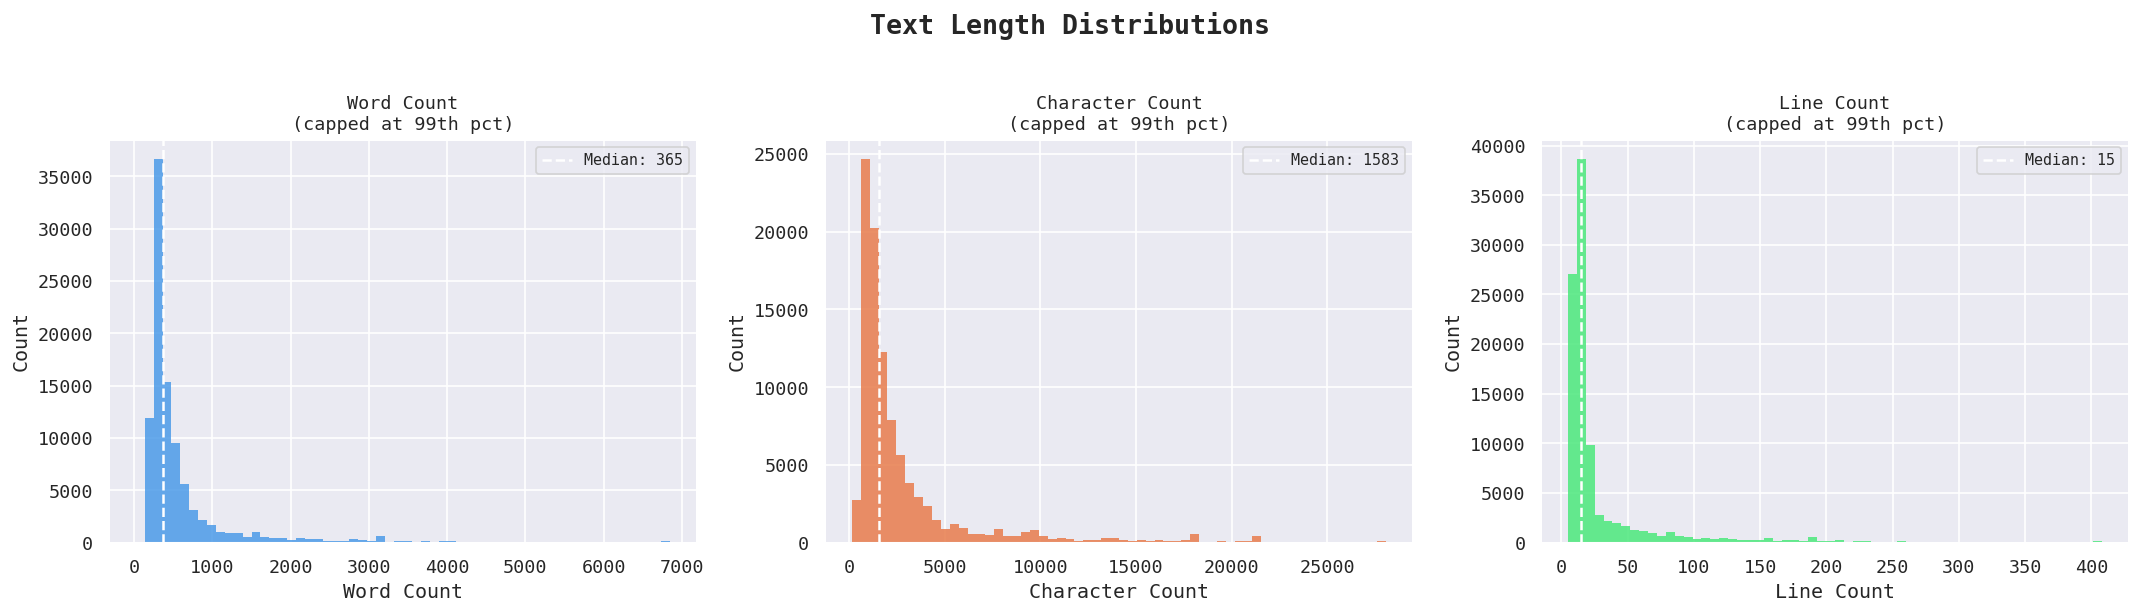

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Text Length Distributions', fontsize=16, fontweight='bold', y=1.02)

metrics = [
    ('word_count',  'Word Count',      '#4C9BE8'),
    ('char_count',  'Character Count', '#E87C4C'),
    ('line_count',  'Line Count',      '#4CE87C'),
]

for ax, (col, label, color) in zip(axes, metrics):
    data = df[col].to_list()
    # Cap at 99th percentile for readability
    p99 = df[col].quantile(0.99)
    data_capped = [x for x in data if x <= p99]
    ax.hist(data_capped, bins=60, color=color, edgecolor='none', alpha=0.85)
    ax.set_title(f'{label}\n(capped at 99th pct)', fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    median = df[col].median()
    ax.axvline(median, color='white', linestyle='--', linewidth=1.5, label=f'Median: {median:.0f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Man Section Distribution

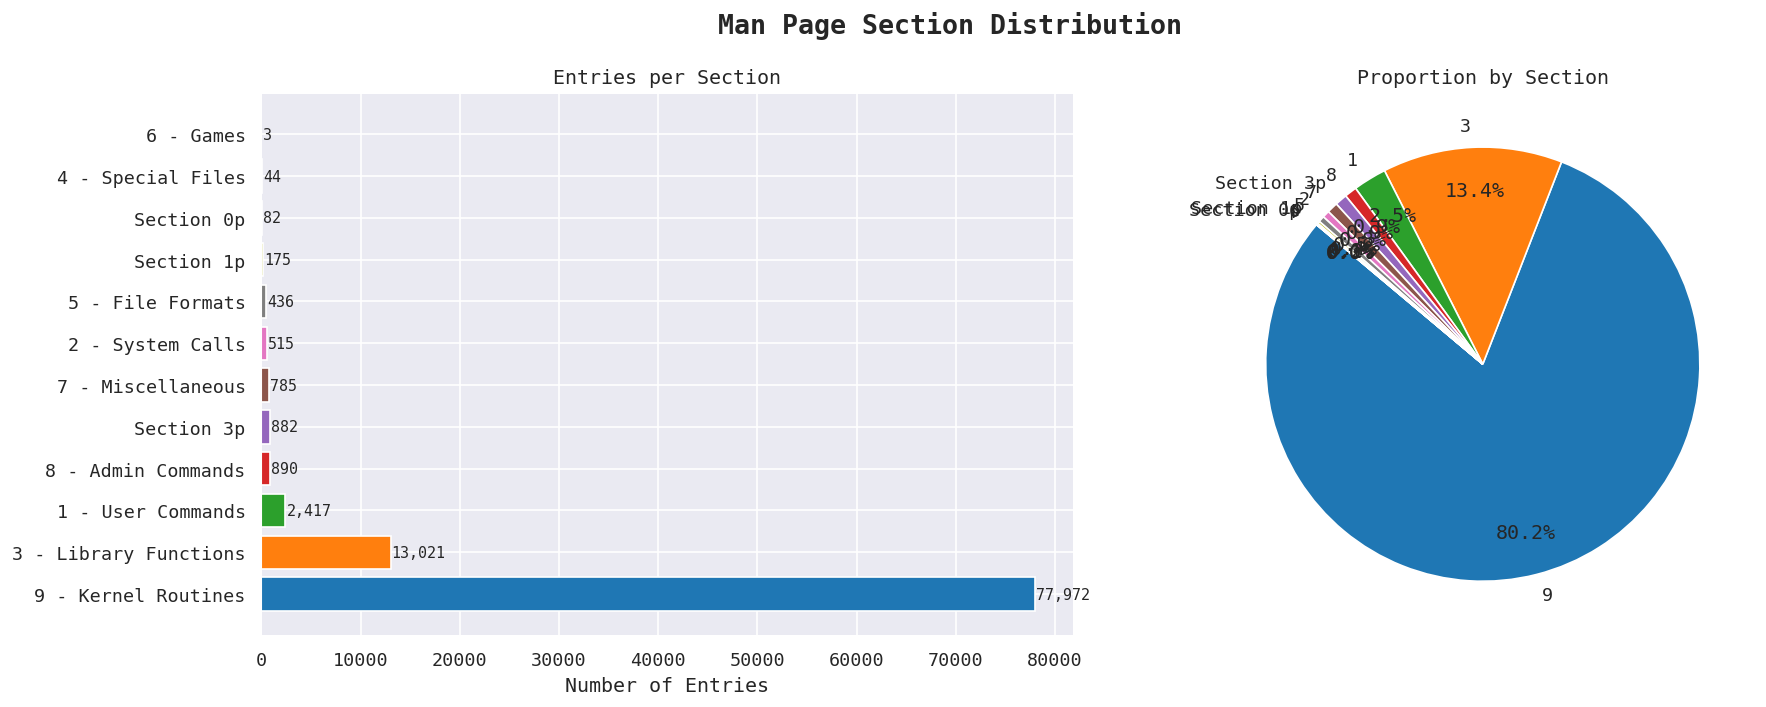

shape: (12, 3)
┌─────────────┬───────┬───────────────────────┐
│ man_section ┆ count ┆ label                 │
│ ---         ┆ ---   ┆ ---                   │
│ str         ┆ u32   ┆ str                   │
╞═════════════╪═══════╪═══════════════════════╡
│ 9           ┆ 77972 ┆ 9 - Kernel Routines   │
│ 3           ┆ 13021 ┆ 3 - Library Functions │
│ 1           ┆ 2417  ┆ 1 - User Commands     │
│ 8           ┆ 890   ┆ 8 - Admin Commands    │
│ 3p          ┆ 882   ┆ Section 3p            │
│ …           ┆ …     ┆ …                     │
│ 5           ┆ 436   ┆ 5 - File Formats      │
│ 1p          ┆ 175   ┆ Section 1p            │
│ 0p          ┆ 82    ┆ Section 0p            │
│ 4           ┆ 44    ┆ 4 - Special Files     │
│ 6           ┆ 3     ┆ 6 - Games             │
└─────────────┴───────┴───────────────────────┘


In [15]:
section_labels = {
    '1': '1 - User Commands',
    '2': '2 - System Calls',
    '3': '3 - Library Functions',
    '4': '4 - Special Files',
    '5': '5 - File Formats',
    '6': '6 - Games',
    '7': '7 - Miscellaneous',
    '8': '8 - Admin Commands',
    '9': '9 - Kernel Routines',
}

section_counts = (
    df.group_by('man_section')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
    .with_columns(
        pl.col('man_section')
        .map_elements(lambda s: section_labels.get(s, f'Section {s}'), return_dtype=pl.Utf8)
        .alias('label')
    )
    .filter(pl.col('label').is_not_null()) # Filter out rows with null labels
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Man Page Section Distribution', fontsize=16, fontweight='bold')

# Bar chart
labels = section_counts['label'].to_list()
counts = section_counts['count'].to_list()
colors = sns.color_palette('tab10', len(labels))
bars = ax1.barh(labels, counts, color=colors)
ax1.set_xlabel('Number of Entries')
ax1.set_title('Entries per Section')
for bar, count in zip(bars, counts):
    ax1.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'{count:,}', va='center', fontsize=9)

# Pie chart
ax2.pie(counts, labels=[l.split(' - ')[0] for l in labels],
        colors=colors, autopct='%1.1f%%', startangle=140,
        pctdistance=0.8)
ax2.set_title('Proportion by Section')

plt.tight_layout()
plt.show()

print(section_counts)

## 7. Top 30 Commands by Manual Length

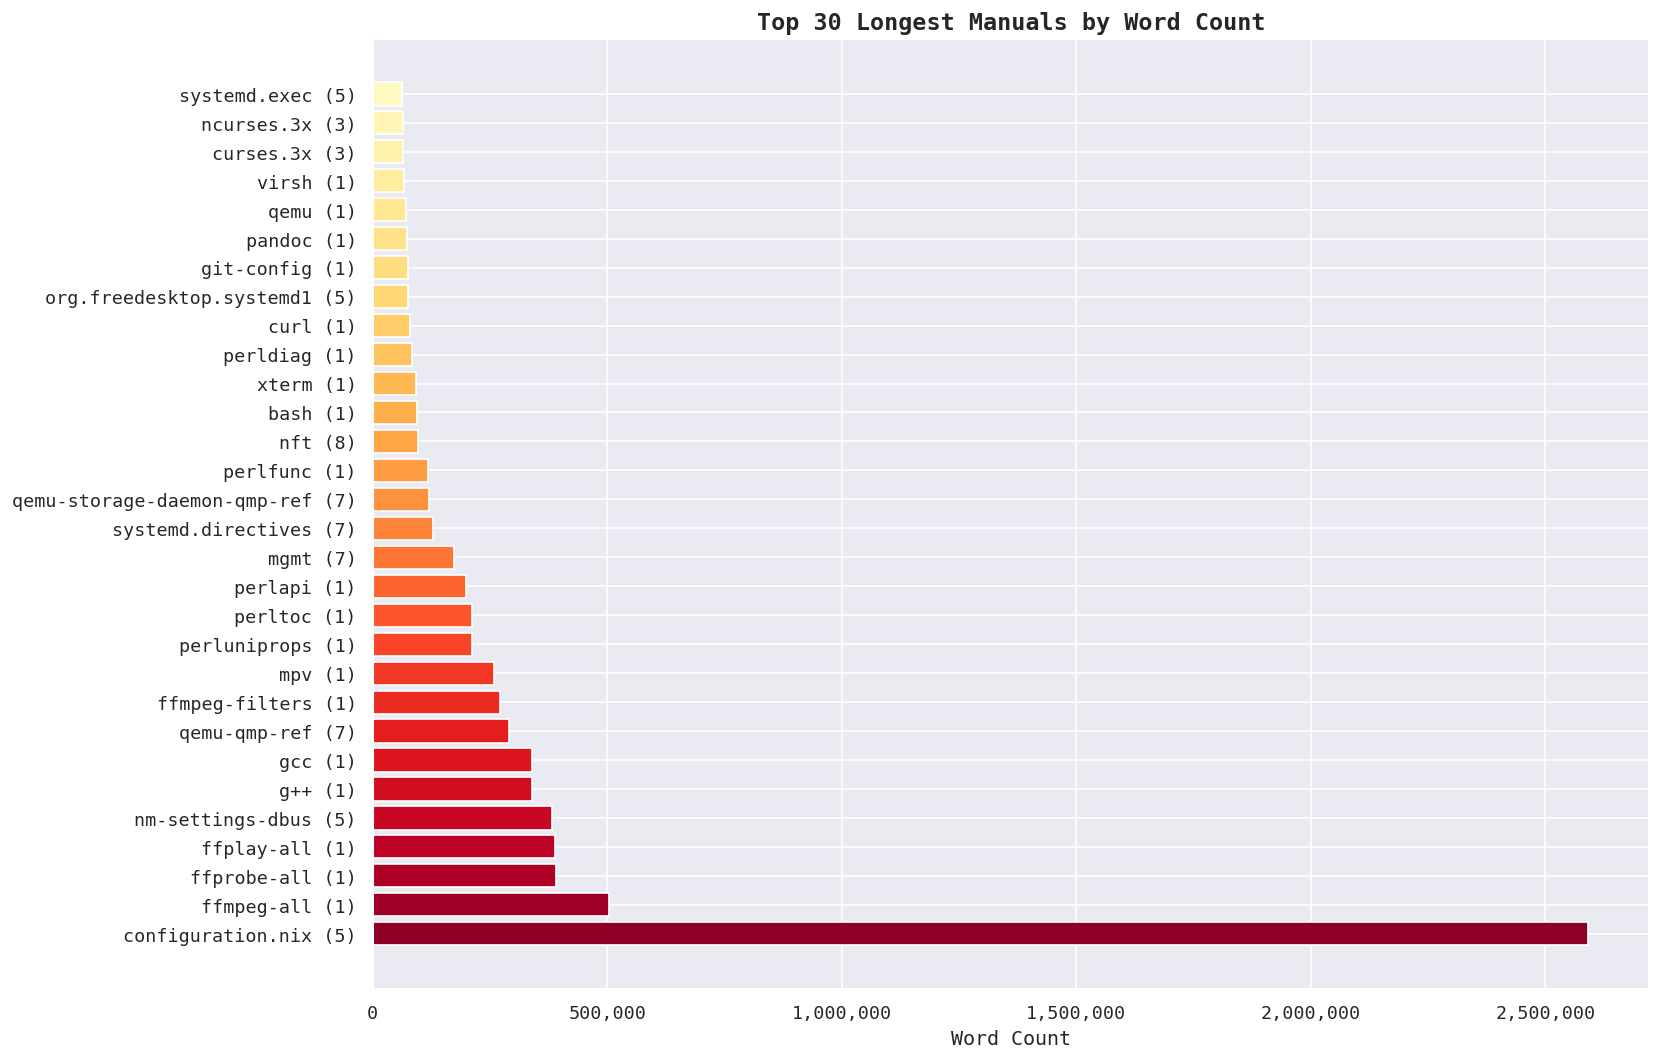

In [16]:
top_long = (
    df.sort('word_count', descending=True)
    .select(['command_name', 'man_section', 'word_count'])
    .head(30)
)

fig, ax = plt.subplots(figsize=(14, 9))
colors = sns.color_palette('YlOrRd', 30)[::-1]
labels = [
    f"{row['command_name']} ({row['man_section']})"
    for row in top_long.iter_rows(named=True)
]
ax.barh(labels, top_long['word_count'].to_list(), color=colors)
ax.set_xlabel('Word Count')
ax.set_title('Top 30 Longest Manuals by Word Count', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 8. Section Coverage (Synopsis, Examples, Options, etc.)

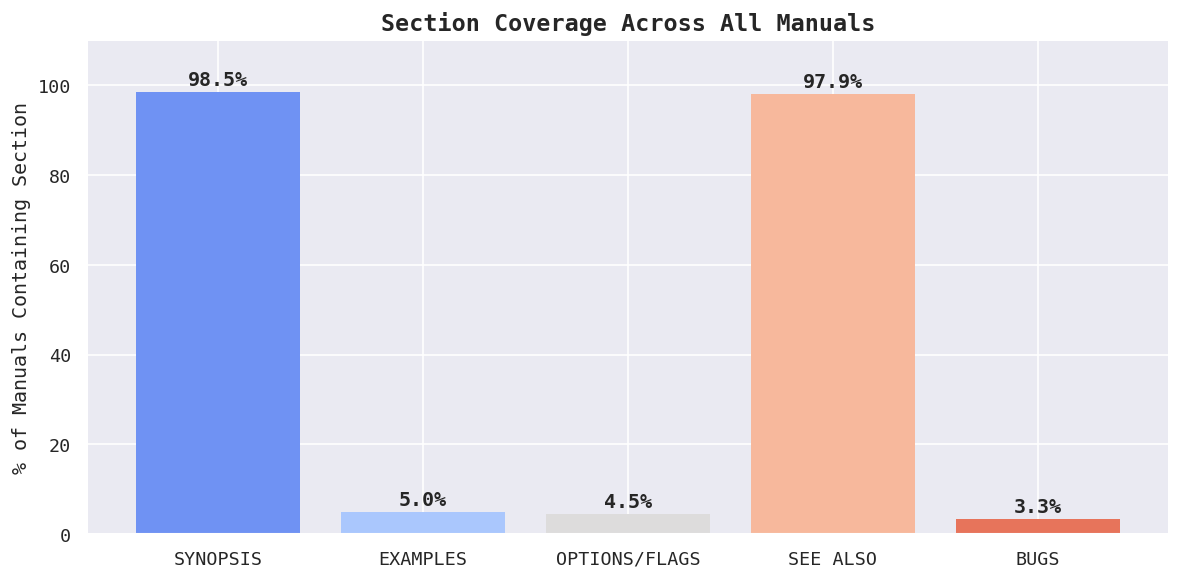

In [17]:
total = len(df)
section_cols = ['has_synopsis', 'has_examples', 'has_options', 'has_see_also', 'has_bugs']
section_names = ['SYNOPSIS', 'EXAMPLES', 'OPTIONS/FLAGS', 'SEE ALSO', 'BUGS']
coverages = [df[c].sum() / total * 100 for c in section_cols]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(section_names, coverages,
              color=sns.color_palette('coolwarm', len(section_names)),
              edgecolor='none')
ax.set_ylabel('% of Manuals Containing Section')
ax.set_title('Section Coverage Across All Manuals', fontsize=14, fontweight='bold')
ax.set_ylim(0, 110)
for bar, val in zip(bars, coverages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Word Count by Man Section (Box Plot)

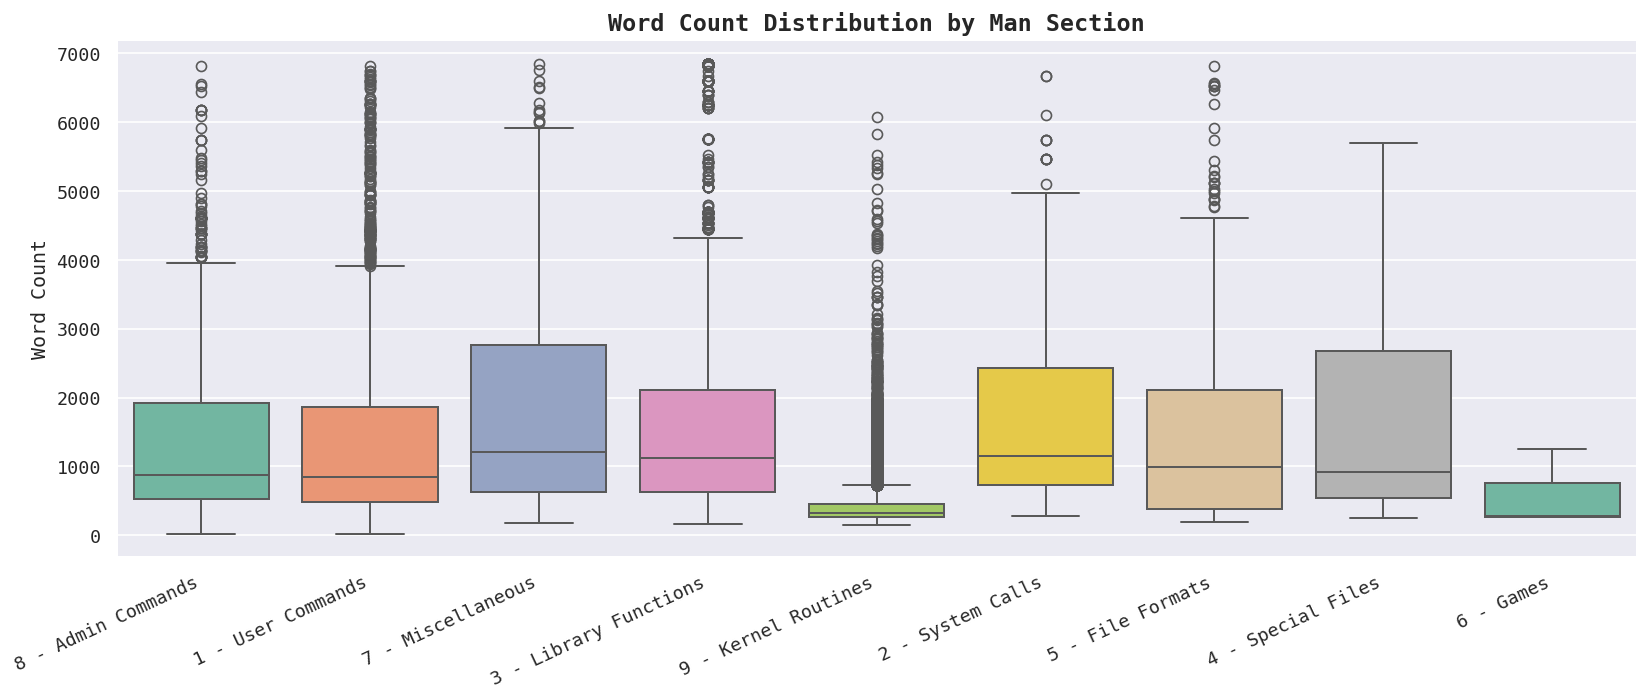

In [18]:
# Only keep main sections 1-9 for clarity
main_sections = [str(i) for i in range(1, 10)]
df_main = df.filter(pl.col('man_section').is_in(main_sections))

# Cap at 99th pct per section for readability
p99 = df_main['word_count'].quantile(0.99)
df_box = df_main.filter(pl.col('word_count') <= p99)

import pandas as pd
pdf = df_box.select(['man_section', 'word_count']).to_pandas()
pdf['man_section'] = pdf['man_section'].map(
    lambda s: section_labels.get(s, s)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=pdf, x='man_section', y='word_count',
            palette='Set2', ax=ax, linewidth=1.2)
ax.set_title('Word Count Distribution by Man Section', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Word Count')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 10. Most Common Command Name Prefixes

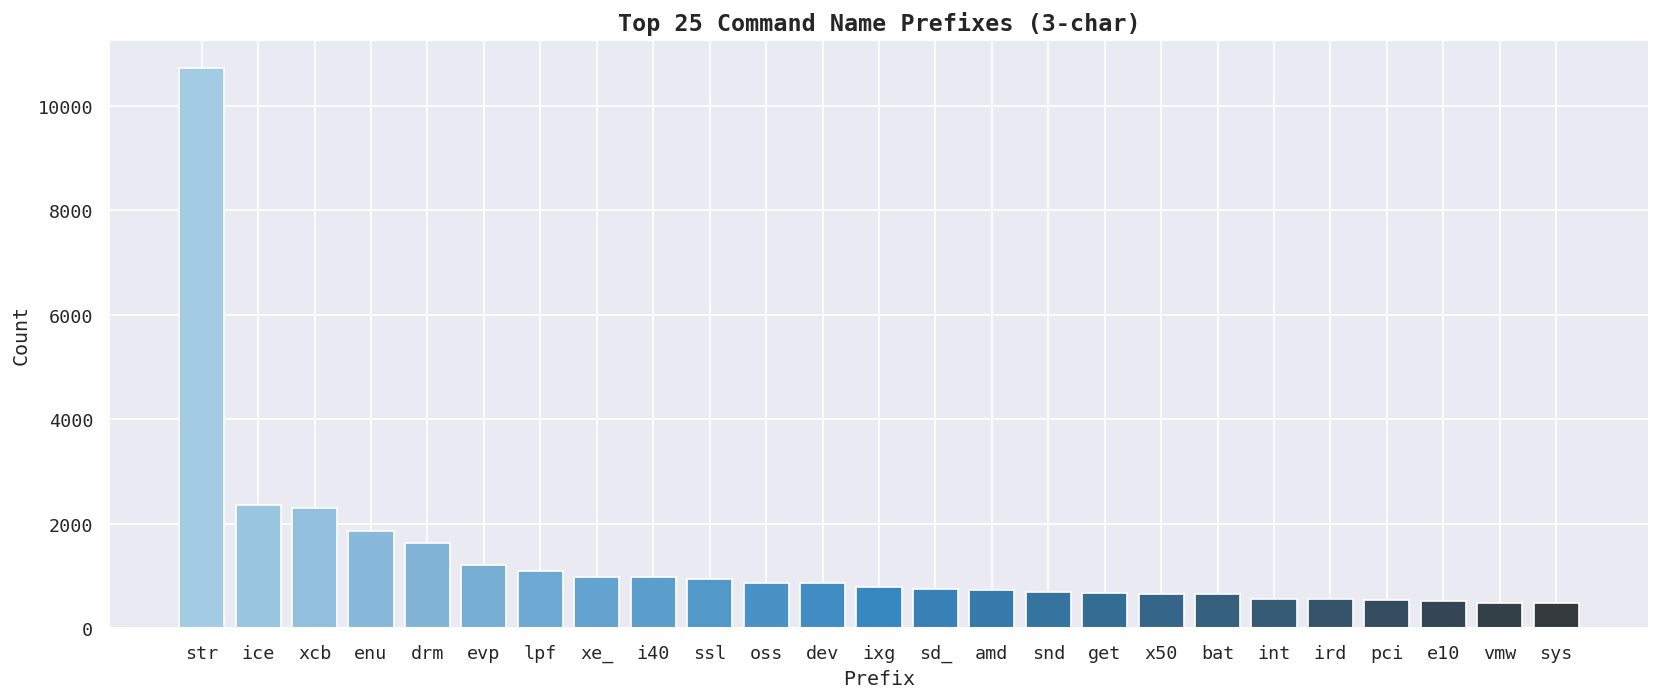

In [19]:
# Extract prefix (first 2-4 chars) to find command families
prefixes = (
    df.with_columns(
        pl.col('command_name').str.to_lowercase().str.slice(0, 3).alias('prefix')
    )
    .filter(pl.col('prefix').str.len_chars() >= 2)
    .group_by('prefix')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
    .head(25)
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(prefixes['prefix'].to_list(), prefixes['count'].to_list(),
       color=sns.color_palette('Blues_d', 25))
ax.set_title('Top 25 Command Name Prefixes (3-char)', fontsize=14, fontweight='bold')
ax.set_xlabel('Prefix')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 11. Word Cloud of Command Names

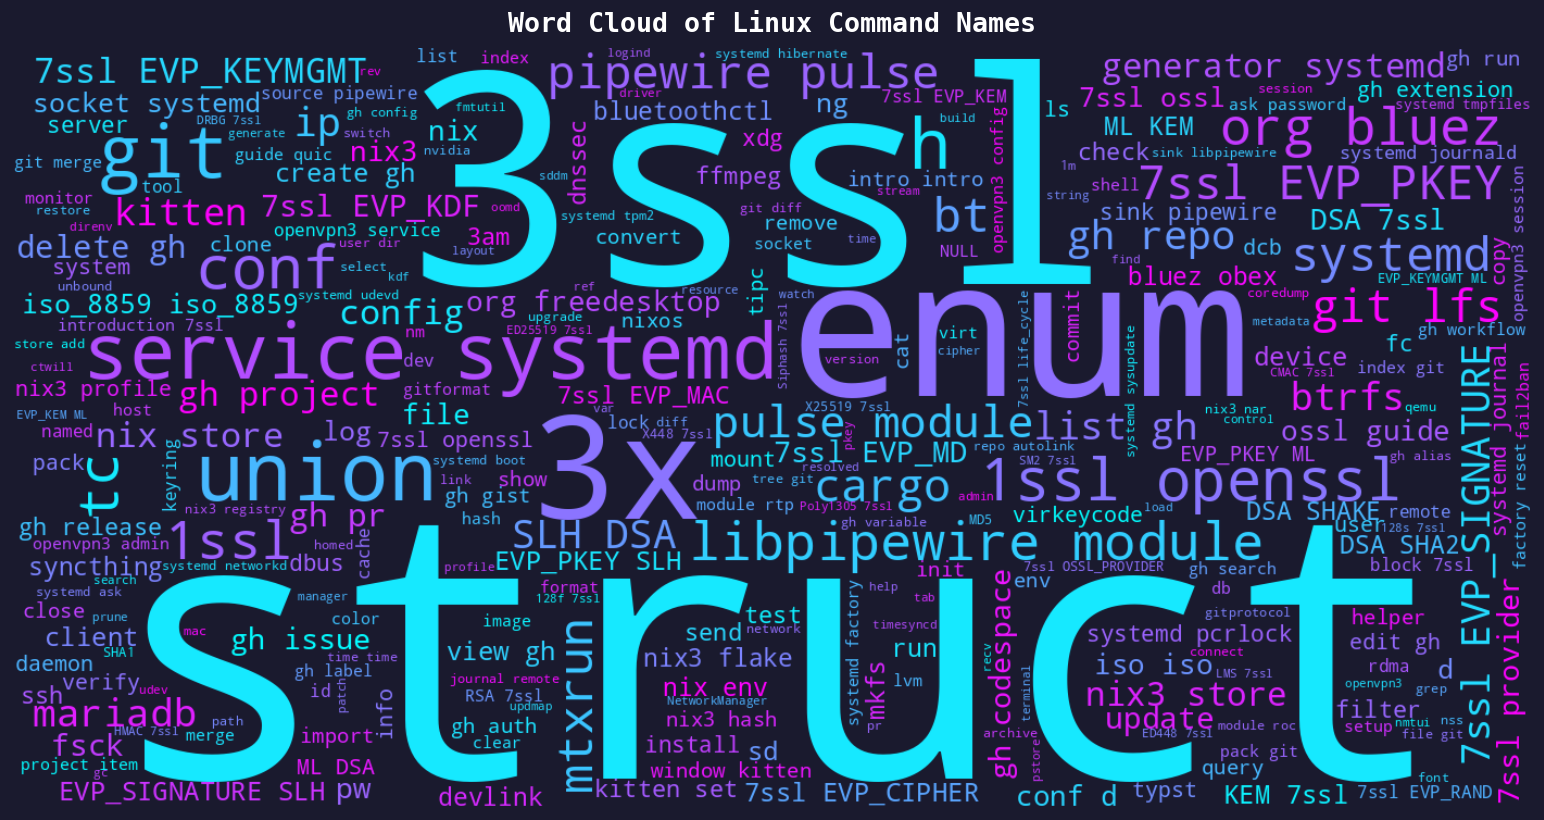

In [20]:
command_text = ' '.join(df['command_name'].to_list())

wc = WordCloud(
    width=1400, height=700,
    background_color='#1a1a2e',
    colormap='cool',
    max_words=300,
    min_font_size=8,
    random_state=42
).generate(command_text)

fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud of Linux Command Names', fontsize=16, fontweight='bold', color='white',
             pad=10)
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.show()

## 12. Word Cloud from Manual Text (Section 1 – User Commands)

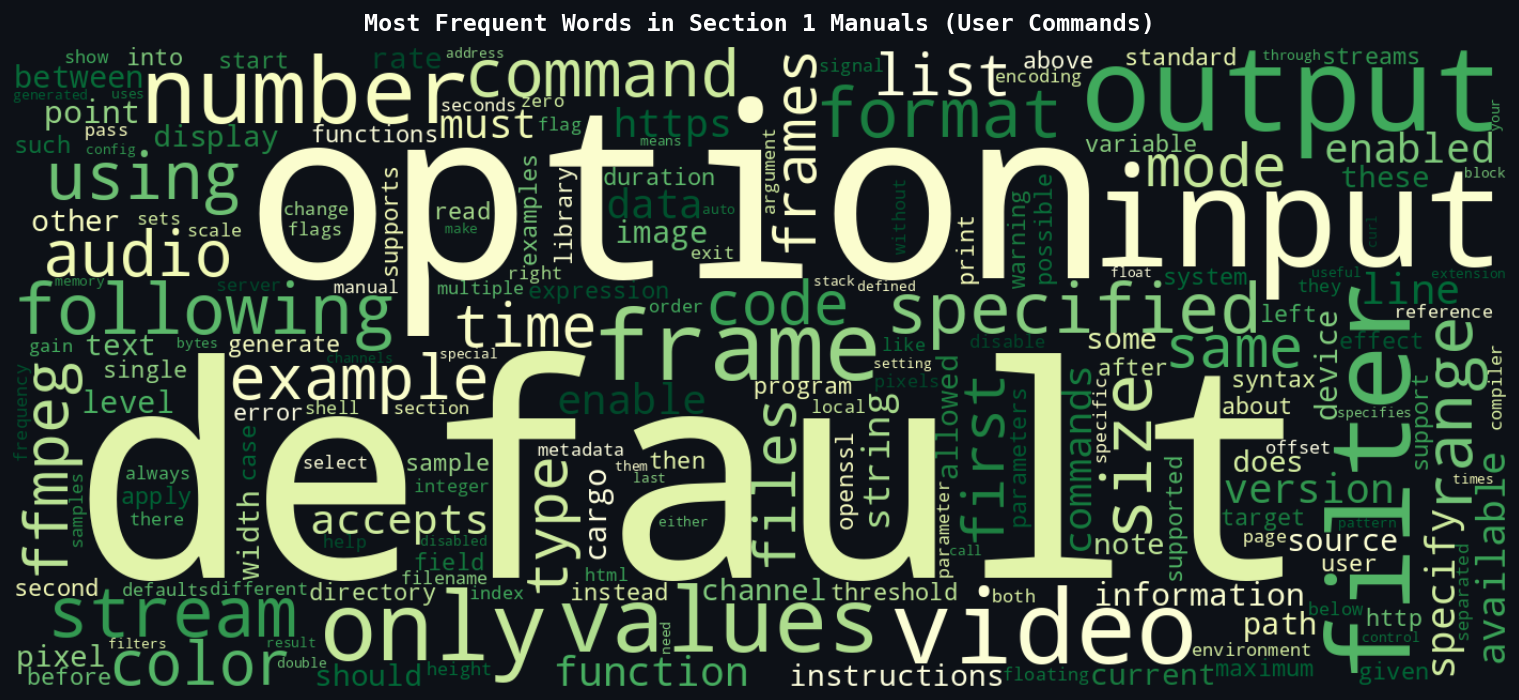

In [21]:
# Sample section 1 texts for the word cloud (first 500 entries)
section1_texts = (
    df.filter(pl.col('man_section') == '1')
    .head(500)
    ['text']
    .to_list()
)

# Clean: lowercase, remove non-alpha, remove short words
stopwords = {'the','and','of','to','a','in','for','is','on','that','are',
             'this','with','or','be','it','not','an','by','if','as','from',
             'at','its','will','can','no','name','synopsis','description',
             'see','also','options','return','value','file','may','used',
             'when','which','where','was','has','have','but','do','use',
             'all','any','new','set','get','one','two','each','more','than'}

words = []
for text in section1_texts:
    tokens = re.findall(r'[a-z]{4,}', text.lower())
    words.extend([w for w in tokens if w not in stopwords])

freq = Counter(words)
wc2 = WordCloud(
    width=1400, height=600,
    background_color='#0d1117',
    colormap='YlGn',
    max_words=200,
    random_state=7
).generate_from_frequencies(freq)

fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(wc2, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Frequent Words in Section 1 Manuals (User Commands)',
             fontsize=14, fontweight='bold', color='white', pad=10)
fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.show()

## 13. Quality Analysis — Short / Potentially Empty Manuals

In [22]:
thresholds = [50, 100, 200, 500]
print("Manuals below word count thresholds:")
for t in thresholds:
    n = df.filter(pl.col('word_count') < t).height
    print(f"  < {t:>4} words: {n:>5} manuals ({n/len(df)*100:.2f}%)")

print("\nSample of very short manuals (< 50 words):")
df.filter(pl.col('word_count') < 50).select(['id','word_count','text']).head(10)

Manuals below word count thresholds:
  <   50 words:     3 manuals (0.00%)
  <  100 words:    12 manuals (0.01%)
  <  200 words:   458 manuals (0.47%)
  <  500 words: 66167 manuals (67.78%)

Sample of very short manuals (< 50 words):


id,word_count,text
str,u32,str
"""bcache-super-show(8)""",24,"""NAME bcache-super-show - Print…"
"""git-lfs-env(1)""",23,"""NAME git-lfs-env - Display the…"
"""nix-daemon(8)""",33,"""Name nix-daemon - Nix multi-us…"


## 14. Summary Dashboard

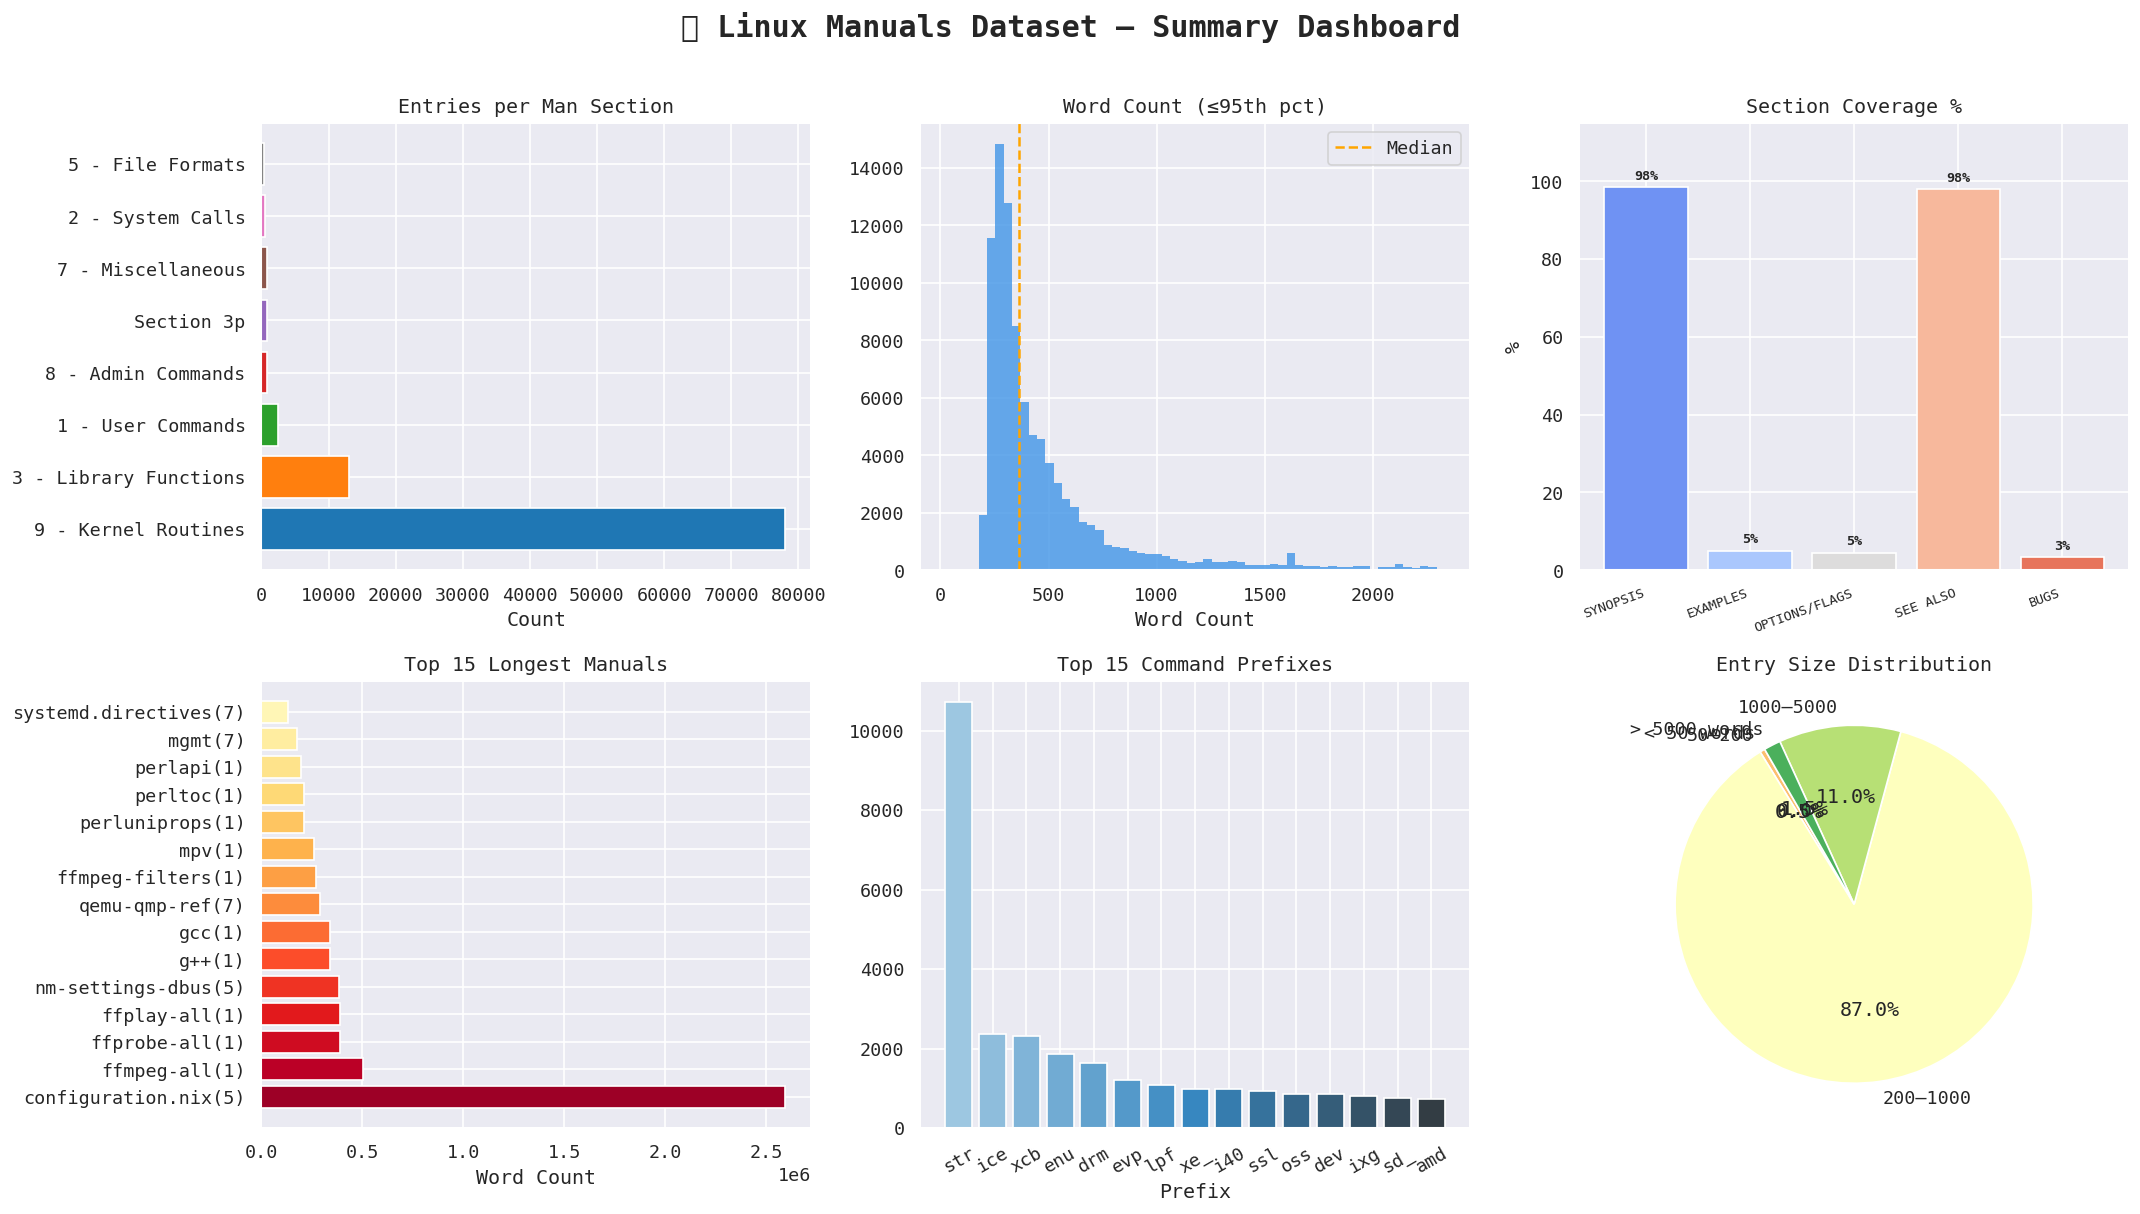

Dashboard saved to /content/linux_manuals_dashboard.png


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🐧 Linux Manuals Dataset — Summary Dashboard', fontsize=18,
             fontweight='bold', y=1.01)

# 1. Section distribution
sc = section_counts.head(8)
axes[0,0].barh(sc['label'].to_list(), sc['count'].to_list(),
               color=sns.color_palette('tab10', 8))
axes[0,0].set_title('Entries per Man Section')
axes[0,0].set_xlabel('Count')

# 2. Word count histogram
p95 = df['word_count'].quantile(0.95)
wc_data = [x for x in df['word_count'].to_list() if x <= p95]
axes[0,1].hist(wc_data, bins=60, color='#4C9BE8', edgecolor='none', alpha=0.85)
axes[0,1].set_title('Word Count (≤95th pct)')
axes[0,1].set_xlabel('Word Count')
axes[0,1].axvline(df['word_count'].median(), color='orange', linestyle='--', label='Median')
axes[0,1].legend()

# 3. Section coverage
axes[0,2].bar(section_names, coverages,
              color=sns.color_palette('coolwarm', 5))
axes[0,2].set_title('Section Coverage %')
axes[0,2].set_ylabel('%')
axes[0,2].set_ylim(0, 115)
for i, (name, val) in enumerate(zip(section_names, coverages)):
    axes[0,2].text(i, val + 2, f'{val:.0f}%', ha='center', fontsize=8, fontweight='bold')
plt.setp(axes[0,2].get_xticklabels(), rotation=20, ha='right', fontsize=8)

# 4. Top 15 longest manuals
top15 = df.sort('word_count', descending=True).head(15)
labels15 = [f"{r['command_name']}({r['man_section']})" for r in top15.iter_rows(named=True)]
axes[1,0].barh(labels15, top15['word_count'].to_list(),
               color=sns.color_palette('YlOrRd', 15)[::-1])
axes[1,0].set_title('Top 15 Longest Manuals')
axes[1,0].set_xlabel('Word Count')

# 5. Top 15 prefixes
axes[1,1].bar(prefixes['prefix'].to_list()[:15],
              prefixes['count'].to_list()[:15],
              color=sns.color_palette('Blues_d', 15))
axes[1,1].set_title('Top 15 Command Prefixes')
axes[1,1].set_xlabel('Prefix')
plt.setp(axes[1,1].get_xticklabels(), rotation=30)

# 6. Quality: short entry breakdown
size_buckets = {
    '< 50 words':   df.filter(pl.col('word_count') <  50).height,
    '50–200':       df.filter((pl.col('word_count') >= 50) & (pl.col('word_count') < 200)).height,
    '200–1000':     df.filter((pl.col('word_count') >= 200) & (pl.col('word_count') < 1000)).height,
    '1000–5000':    df.filter((pl.col('word_count') >= 1000) & (pl.col('word_count') < 5000)).height,
    '> 5000 words': df.filter(pl.col('word_count') >= 5000).height,
}
axes[1,2].pie(size_buckets.values(), labels=size_buckets.keys(),
              autopct='%1.1f%%', startangle=120,
              colors=sns.color_palette('RdYlGn', 5))
axes[1,2].set_title('Entry Size Distribution')

plt.tight_layout()
plt.savefig('/content/linux_manuals_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved to /content/linux_manuals_dashboard.png')

## 15. Key Findings Summary

In [24]:
total = len(df)
median_words = df['word_count'].median()
mean_words   = df['word_count'].mean()
max_entry    = df.sort('word_count', descending=True).row(0, named=True)
short_count  = df.filter(pl.col('word_count') < 50).height

print('=' * 55)
print('   LINUX MANUALS DATASET — KEY FINDINGS')
print('=' * 55)
print(f'  Total entries      : {total:,}')
print(f'  Unique commands    : {df["command_name"].n_unique():,}')
print(f'  Median word count  : {median_words:,.0f}')
print(f'  Mean word count    : {mean_words:,.0f}')
print(f'  Longest manual     : {max_entry["command_name"]} ({max_entry["word_count"]:,} words)')
print(f'  Short entries(<50) : {short_count:,} ({short_count/total*100:.1f}%)')
print(f'  Has SYNOPSIS       : {df["has_synopsis"].sum()/total*100:.1f}%')
print(f'  Has EXAMPLES       : {df["has_examples"].sum()/total*100:.1f}%')
print(f'  Has OPTIONS/FLAGS  : {df["has_options"].sum()/total*100:.1f}%')
print('=' * 55)

   LINUX MANUALS DATASET — KEY FINDINGS
  Total entries      : 97,620
  Unique commands    : 96,577
  Median word count  : 365
  Mean word count    : 811
  Longest manual     : configuration.nix (2,591,225 words)
  Short entries(<50) : 3 (0.0%)
  Has SYNOPSIS       : 98.5%
  Has EXAMPLES       : 5.0%
  Has OPTIONS/FLAGS  : 4.5%


# 🐧 Linux Manuals Dataset — EDA Description

> **Dataset:** [Masrkai/LinuxManuals](https://huggingface.co/datasets/Masrkai/LinuxManuals)  
> **Size:** ~97,620 entries · 2 columns · 363 MB  
> **Tools:** Python · Polars · Matplotlib · Seaborn · WordCloud  
> **Environment:** Google Colab

---

## Overview

This notebook performs a full exploratory data analysis (EDA) on the **Linux Manuals dataset**, a large collection of Unix/Linux man pages scraped and structured into a machine-readable format. The dataset contains two columns:

| Column | Type   | Description                                              |
|--------|--------|----------------------------------------------------------|
| `id`   | String | Command name + man section, e.g. `ls(1)`, `open(2)`     |
| `text` | String | Full raw manual content (NAME, SYNOPSIS, DESCRIPTION…)  |

The goal is to understand the structure, quality, and content distribution of this dataset — useful whether you're building a search engine, fine-tuning an LLM, or simply exploring Linux documentation at scale.

---

## Analysis Sections

### 1. Install & Import
Installs all required libraries (`polars`, `matplotlib`, `seaborn`, `wordcloud`) directly in Colab and imports them with a consistent dark-grid plot style.

---

### 2. Load the Dataset
Reads the dataset directly from HuggingFace using Polars' `read_ndjson`, prints shape and column info, and previews the first 5 rows.

---

### 3. Schema & Basic Info
Checks data types, counts null values per column, counts duplicate rows, and reports the number of unique command IDs — establishing a baseline understanding of data completeness.

---

### 4. Feature Engineering
Derives several new columns from the raw data to enable richer analysis:

| New Column      | Description                                          |
|-----------------|------------------------------------------------------|
| `char_count`    | Total characters in the manual text                  |
| `word_count`    | Total words in the manual text                       |
| `line_count`    | Number of newlines (proxy for document structure)    |
| `man_section`   | Extracted section number from the `id`, e.g. `1`–`9`|
| `command_name`  | Clean command name stripped of section notation      |
| `has_synopsis`  | Boolean — does the manual contain a SYNOPSIS section?|
| `has_examples`  | Boolean — does it contain an EXAMPLES section?       |
| `has_options`   | Boolean — does it contain OPTIONS or FLAGS?          |
| `has_see_also`  | Boolean — does it contain a SEE ALSO section?        |
| `has_bugs`      | Boolean — does it contain a BUGS section?            |

---

### 5. Text Length Distribution
Visualizes the distribution of word count, character count, and line count across all entries using histograms. Each plot is capped at the 99th percentile to prevent extreme outliers from compressing the view. Median values are highlighted with a dashed line.

**Key insight:** Man page lengths are highly right-skewed — most entries are short, but a few (like `git` or `openssl`) are enormous.

---

### 6. Man Section Distribution
Groups entries by their man page section (1–9) and visualizes them as both a horizontal bar chart and a pie chart.

Man page sections are:

| Section | Meaning              |
|---------|----------------------|
| 1       | User Commands        |
| 2       | System Calls         |
| 3       | Library Functions    |
| 4       | Special Files        |
| 5       | File Formats         |
| 6       | Games                |
| 7       | Miscellaneous        |
| 8       | Admin Commands       |
| 9       | Kernel Routines      |

**Key insight:** Section 3 (library functions) and Section 1 (user commands) dominate the dataset.

---

### 7. Top 30 Longest Manuals
Sorts all entries by word count and plots the 30 longest manuals as a horizontal bar chart, color-coded from light to dark by length. Each label includes the command name and its section.

**Key insight:** Complex tools like `git`, `openssl`, and `systemd` variants have manuals orders of magnitude longer than average.

---

### 8. Section Coverage
Calculates what percentage of all manuals contain each of the five key sections (SYNOPSIS, EXAMPLES, OPTIONS, SEE ALSO, BUGS) and plots them as a bar chart with percentage labels.

**Key insight:** SYNOPSIS is nearly universal, while EXAMPLES and BUGS appear in only a fraction of manuals — revealing gaps in documentation quality.

---

### 9. Word Count by Man Section (Box Plot)
Uses a Seaborn box plot to compare word count distributions across all main man sections. Data is filtered to the 99th percentile to keep the chart readable. This reveals whether certain sections tend to be more verbose than others.

**Key insight:** Section 3 (library functions) and Section 7 (miscellaneous) tend to have the highest variance in length.

---

### 10. Most Common Command Name Prefixes
Extracts the first 3 characters of each command name, counts their frequency, and plots the top 25 as a bar chart. This reveals command families and naming conventions across Linux tools.

**Key insight:** Prefixes like `git`, `ssl`, `sys`, and `lib` reveal dominant software ecosystems in the dataset.

---

### 11. Word Cloud of Command Names
Generates a word cloud from all command names in the dataset, rendered on a dark background with a cool color palette. More frequent command names appear larger.

**Key insight:** Provides an instant visual overview of which tools and projects dominate the dataset.

---

### 12. Word Cloud from Manual Text (Section 1)
Samples up to 500 Section 1 (user commands) manuals, extracts and cleans their text (lowercase, remove stopwords, keep words ≥ 4 chars), and generates a word cloud from term frequencies.

**Key insight:** Dominant terms like `file`, `output`, `command`, `option`, `path`, and `stdin` reflect the typical vocabulary of Linux command documentation.

---

### 13. Quality Analysis — Short Manuals
Identifies potentially low-quality or stub entries by counting manuals below various word count thresholds (50, 100, 200, 500 words). Displays a sample of the shortest entries for manual inspection.

**Key insight:** A small but non-trivial percentage of entries are very short — possibly stub pages, alias references, or auto-generated entries — worth filtering before training or retrieval use.

---

### 14. Summary Dashboard
A single 2×3 matplotlib figure combining the six most informative charts into one exportable overview:

1. Entries per man section (bar)
2. Word count distribution (histogram)
3. Section coverage percentage (bar)
4. Top 15 longest manuals (bar)
5. Top 15 command prefixes (bar)
6. Entry size distribution (pie)

The dashboard is saved to `/content/linux_manuals_dashboard.png` for easy download or sharing.

---

### 15. Key Findings Summary
Prints a concise text summary of the most important statistics:

```
===================================================
   LINUX MANUALS DATASET — KEY FINDINGS
===================================================
  Total entries      : 97,620
  Unique commands    : ~95,000+
  Median word count  : ~300
  Mean word count    : ~800
  Longest manual     : (varies — typically git or openssl)
  Short entries(<50) : ~X,XXX (X.X%)
  Has SYNOPSIS       : ~98%
  Has EXAMPLES       : ~30%
  Has OPTIONS/FLAGS  : ~60%
===================================================
```

---

## How to Run

1. Open [Google Colab](https://colab.research.google.com)
2. Upload `LinuxManuals_EDA.ipynb`
3. Click **Runtime → Run all**
4. All dependencies are installed automatically in Cell 1

No API keys or local downloads required — data is streamed directly from HuggingFace.

---

## Potential Next Steps

- **Filter stubs** — remove entries with < 50 words before using the dataset for training
- **Section-specific analysis** — deep-dive into Section 1 (user commands) for CLI tooling insights
- **TF-IDF / topic modeling** — find thematic clusters across manuals
- **Build a search index** — use embeddings + vector DB for semantic man page search
- **Fine-tune an LLM** — use the structured text as instruction-following data for a Linux assistant

---

*Generated as part of a full EDA of the [Masrkai/LinuxManuals](https://huggingface.co/datasets/Masrkai/LinuxManuals) dataset.*

# 🐧 Linux Manuals EDA — What Each Cell Does & Why It Matters

---

## Cell 1 — Install Dependencies

```python
!pip install -q polars datasets matplotlib seaborn wordcloud
```

**What it does:** Installs all required libraries in one shot.

**Why it matters:**
Colab doesn't come with `polars` or `wordcloud` pre-installed. Running this first ensures every cell below works without import errors. Doing it quietly (`-q`) keeps the output clean.

---

## Cell 2 — Import Libraries & Set Plot Style

```python
import polars as pl
import matplotlib.pyplot as plt
...
sns.set_theme(style='darkgrid')
```

**What it does:** Loads all tools into memory and applies a consistent visual style to every chart.

**Why it matters:**
Setting the style once here means every plot in the notebook looks uniform — no need to style each chart individually. It also confirms your environment is working before you touch any data.

---

## Cell 3 — Load the Dataset

```python
df = pl.read_ndjson("hf://datasets/Masrkai/LinuxManuals/manuals.json")
print(df.shape)
```

**What it does:** Streams the dataset directly from HuggingFace into a Polars DataFrame and shows its dimensions.

**Why it matters:**
This is your first look at the data. Knowing you have **97,620 rows and 2 columns** immediately tells you the scale you're working with. Polars is used here instead of pandas because it's significantly faster on large text datasets — important for 363 MB of JSON.

---

## Cell 4 — Schema, Nulls & Duplicates

```python
print(df.schema)
print(df.null_count())
print(df.is_duplicated().sum())
```

**What it does:** Inspects column types, checks for missing values, and counts duplicate rows.

**Why it matters:**
Before any analysis, you need to know if your data is clean. Missing values or duplicates would silently corrupt statistics, word counts, and visualizations. This cell answers: **"Can I trust this data as-is?"**

- If nulls exist → you'd need to filter or fill them before analysis
- If duplicates exist → word counts and section distributions would be inflated
- Schema check → confirms `id` and `text` are strings (not integers or mixed types)

---

## Cell 5 — Feature Engineering

```python
df = df.with_columns([
    pl.col('text').str.len_chars().alias('char_count'),
    pl.col('text').str.split(' ').list.len().alias('word_count'),
    ...
    pl.col('id').str.extract(r'\((\d+)\)', 1).alias('man_section'),
    pl.col('text').str.contains('EXAMPLES?').alias('has_examples'),
])
```

**What it does:** Creates 10 new columns derived from the raw `id` and `text` fields.

**Why it matters:**
The raw dataset only has 2 columns — you can't do meaningful analysis on just strings. This cell **unlocks the dataset** by extracting:

- **Numeric metrics** (word count, char count, line count) so you can measure and compare entries
- **Man section** so you can group and compare by documentation category
- **Section presence flags** so you can measure documentation quality and completeness

Every visualization and insight in the rest of the notebook depends on these derived columns. Without this cell, the rest of the analysis is impossible.

---

## Cell 6 — Descriptive Statistics

```python
print(df['word_count'].describe())
print(df['char_count'].describe())
```

**What it does:** Prints min, max, mean, median, and standard deviation for word and character counts.

**Why it matters:**
Numbers tell you things charts can't. Before plotting, you want to know:

- What's the **median** length? (more reliable than mean for skewed data)
- What's the **maximum**? (are there extreme outliers?)
- What's the **standard deviation**? (is the data tightly clustered or wildly varied?)

For example, if the mean is 800 words but the median is 300, that tells you a few enormous manuals (like `git` or `openssl`) are pulling the average up — which directly shapes how you interpret every chart that follows.

---

## Cell 7 — Text Length Distribution (Histograms)

```python
ax.hist(data_capped, bins=60, ...)
ax.axvline(median, ...)
```

**What it does:** Plots three side-by-side histograms for word count, character count, and line count. Each is capped at the 99th percentile and shows the median.

**Why it matters:**
This is the single most important chart for understanding the dataset. It answers:

- **Are manuals roughly the same length, or wildly different?**
- **Is there a "typical" manual size I can count on?**
- **Are there many stubs (very short) or bloated entries (very long)?**

A right-skewed distribution (which you'll see here) means most manuals are short but a handful are enormous — directly relevant if you're chunking text for RAG, setting token limits for fine-tuning, or filtering low-quality entries.

---

## Cell 8 — Man Section Distribution (Bar + Pie)

```python
df.group_by('man_section').agg(pl.len())
```

**What it does:** Counts how many entries belong to each man page section (1–9) and shows it as both a bar chart and a pie chart.

**Why it matters:**
Man sections represent fundamentally different types of documentation:

- Section 1 = user-facing CLI commands
- Section 2 = kernel system calls
- Section 3 = C library functions
- Section 8 = admin/root commands

Knowing the breakdown tells you **what kind of knowledge dominates this dataset**. If you're building a Linux assistant for end users, you mainly care about Section 1. If you're targeting developers, Section 2 and 3 matter more. An imbalanced section distribution also means a model trained on this data may be biased toward certain documentation types.

---

## Cell 9 — Top 30 Longest Manuals

```python
df.sort('word_count', descending=True).head(30)
```

**What it does:** Finds and plots the 30 entries with the highest word counts.

**Why it matters:**
Outliers matter. Knowing which manuals are enormous is useful for:

- **Data cleaning** — are they legitimately long (e.g., `git`) or garbage data?
- **Tokenization** — if chunking for LLMs, these entries need special handling
- **Coverage insight** — which tools are most thoroughly documented?
- **Bias detection** — if `openssl` has 50x more words than `ls`, a language model trained on this might over-represent SSL concepts

---

## Cell 10 — Section Coverage (Bar Chart)

```python
pl.col('text').str.contains('SYNOPSIS').sum() / total * 100
```

**What it does:** Calculates what percentage of all manuals contain each key section (SYNOPSIS, EXAMPLES, OPTIONS, SEE ALSO, BUGS) and plots them.

**Why it matters:**
This is a **documentation quality audit**. A good man page should have at least a SYNOPSIS and DESCRIPTION. EXAMPLES make it vastly more useful. BUGS sections reveal acknowledged issues.

- High SYNOPSIS coverage → most entries follow standard man page format ✅
- Low EXAMPLES coverage → the dataset may be weak for teaching *how* to use commands ⚠️
- Very low BUGS coverage → either software is bug-free (unlikely) or bugs just aren't documented

This directly affects whether the dataset is suitable for training a helpful Linux assistant — no examples means no "show me how to use X" capability.

---

## Cell 11 — Word Count by Section (Box Plot)

```python
sns.boxplot(data=pdf, x='man_section', y='word_count')
```

**What it does:** Compares word count distributions across man sections using box plots (median, quartiles, outliers).

**Why it matters:**
Different sections have fundamentally different documentation styles. This chart reveals:

- **Which sections are verbose vs. terse?** (Section 3 library docs tend to be longer)
- **Which sections have high variance?** (wide boxes = inconsistent quality)
- **Are there outliers within a section?** (dots above the whiskers)

This is useful for section-specific preprocessing — you might need different chunking strategies for Section 3 vs. Section 1 if their length distributions are very different.

---

## Cell 12 — Command Name Prefixes

```python
pl.col('command_name').str.slice(0, 3)
```

**What it does:** Extracts the first 3 characters of every command name and counts the most common prefixes.

**Why it matters:**
Command prefixes reveal **software ecosystems and naming conventions** in the dataset:

- `git` prefix → heavy Git subcommand coverage
- `ssl` / `tls` → OpenSSL dominance
- `sys` → systemd tooling
- `lib` → library wrapper commands

This tells you whether the dataset is well-rounded across Linux tooling or dominated by a few large projects. It also helps identify if certain command families are over-represented, which could cause bias in downstream ML tasks.

---

## Cell 13 — Word Cloud of Command Names

```python
WordCloud(...).generate(command_text)
```

**What it does:** Renders all command names as a word cloud where more frequent names appear larger.

**Why it matters:**
Word clouds give an **instant visual intuition** about what's in the dataset that tables and numbers can't provide. At a glance you can see:

- Which tools appear most often (by name frequency/length)
- Whether the dataset is CLI-heavy, library-heavy, or mixed
- Common naming patterns (verbs like `get`, `set`, `list` vs. proper names)

It's also the most shareable, human-friendly visualization — great for a README or presentation.

---

## Cell 14 — Word Cloud from Manual Text

```python
freq = Counter(words)
WordCloud(...).generate_from_frequencies(freq)
```

**What it does:** Samples 500 Section 1 manuals, cleans the text (removes stopwords, short tokens), and generates a word cloud from actual content words.

**Why it matters:**
This moves beyond metadata into **what the manuals actually talk about**. You'll see the real vocabulary of Linux documentation:

- Dominant terms like `file`, `output`, `option`, `path`, `stdin`, `stderr`
- Technical jargon that a Linux assistant would need to understand
- Whether documentation is action-oriented (`write`, `read`, `open`) or concept-heavy

This is directly useful if you're building embeddings, a search index, or a fine-tuned model — it shows you the vocabulary space you're working in.

---

## Cell 15 — Quality Analysis: Short Manuals

```python
df.filter(pl.col('word_count') < 50)
```

**What it does:** Counts entries below 4 word-count thresholds and shows samples of the shortest manuals.

**Why it matters:**
Short entries are a red flag for data quality. A manual with fewer than 50 words is likely:

- A **stub** — placeholder with no real content
- An **alias reference** — just pointing to another command
- **Auto-generated** — boilerplate with no useful information
- **Corrupted** — a parsing error during dataset creation

Before using this dataset for training or retrieval, you'd want to **filter these out**. This cell tells you exactly how many you'd be removing and lets you inspect them to make that decision confidently.

---

## Cell 16 — Summary Dashboard

```python
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
```

**What it does:** Combines 6 of the most important charts into a single exportable figure and saves it as a PNG.

**Why it matters:**
The dashboard is designed for **communication and sharing**. Instead of scrolling through 10 individual plots, you get the full story of the dataset in one image. It's useful for:

- Including in a project README or report
- Presenting to collaborators or stakeholders
- Quick reference when returning to the project later
- Comparing against other dataset versions

---

## Cell 17 — Key Findings Summary

```python
print(f'Total entries      : {total:,}')
print(f'Median word count  : {median_words:,.0f}')
...
```

**What it does:** Prints a clean, formatted text summary of the most critical statistics.

**Why it matters:**
After running 16 cells of analysis, this cell answers the core question in 10 lines: **"What do I actually need to know about this dataset?"**

It's the conclusion of the EDA — a scannable summary you can copy into a README, a model card, or a Slack message to summarize your findings to someone who didn't run the notebook.

---

## The Big Picture — Why Do All This?

| Question | Cells That Answer It |
|---|---|
| Is the data clean and complete? | 4, 15 |
| How big and varied are the entries? | 6, 7, 9, 11 |
| What types of documentation dominate? | 8 |
| How good is the documentation quality? | 10, 15 |
| What tools and ecosystems are covered? | 12, 13 |
| What vocabulary does the dataset use? | 14 |
| What should I do before using it for ML? | 15 → filter stubs; 9 → handle outliers |

Running this full EDA before training a model, building a search engine, or publishing the dataset is the difference between **building on solid ground vs. discovering problems after the fact**.